# **03. Neighborhood & Zoning Analysis**


### **Introduction**

House prices can vary depending on where a property is located and how the land is zoned. In this project, we use housing data from Ames, Iowa, to study how neighborhood characteristics and zoning features affect house prices. The goal is to understand whether factors such as neighborhood, zoning type, and location are associated with differences in property values.


### **Project Objectives**

**1. What impact does geographic location have on property values in Ames, Iowa?**

**2. How does the different type of zoning affect property prices in Ames, Iowa?**


| Metric | Formulation |
|---|---|
| Average Sale Price | `AVG(SalePrice)` |
| Sale Price Per Square Foot | `SalePrice / GrLivArea` |



#### **Ames Housing Data Description**

The data was collected by De Cock where 81 dimensions were recorded for 1460 properties in Ames IA.

Brief description of columns:

**1. Identification**
- **Id:** Property ID (unique identifier)
- **SalePrice:** Target variable — final selling price
- **GrLivArea:** Above-ground living area
- **YrSold:** Year sold
- **MSZoning:** Zoning classification
- **Neighborhood:** Physical location within Ames

**This dataset contains information on individual house sales in Ames, Iowa, from 2006 to 2010, including location, zone informations etc., and sales data.**


## **1. Loading Dataset**

In [2]:
import sys
import importlib
sys.path.append("..")

from src.utilis import *
#importlib.reload(utilis)


In [3]:
# define path
parent_path = Path.cwd().parent
data_path = parent_path.joinpath("data", "raw")
processed_path = parent_path.joinpath("data", "processed")

org_files = []
display_md("**Original Files :**")
for file in data_path.rglob("*.csv"):
    org_files.append(file)
    print(org_files.index(file), " ", file.name)

pro_files = []
display_md("**Cleaned Files :**")
for fle in processed_path.rglob("*"):
    pro_files.append(fle)
    print(pro_files.index(fle), " ", fle.name)


**Original Files :**

0   sample_submission.csv
1   test.csv
2   train.csv


**Cleaned Files :**

0   .gitkeep
1   test_cleaned.csv
2   train_cleaned.csv


In [23]:
display_md("**Loading Original Datasets :**")

# Load original data 
train_org = load_data(org_files[2])
test_org = load_data(org_files[1])    

# standardize the column names
train_org.columns = train_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
test_org.columns = test_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

display_md("**Original Training and Testing data Shape**")

print("Original Training data shape: ", train_org.shape)
print("Original Testing data shape: ", test_org.shape)

display_md("**Duplicate Rows in  Data**")

print("Number of duplicate rows in training data: ", train_org.duplicated().sum())
print("Number of duplicate rows in testing data ", test_org.duplicated().sum())


**Loading Original Datasets :**

Data loaded successfully!
Data loaded successfully!


**Original Training and Testing data Shape**

Original Training data shape:  (1460, 81)
Original Testing data shape:  (1459, 80)


**Duplicate Rows in  Data**

Number of duplicate rows in training data:  0
Number of duplicate rows in testing data  0


In [5]:
# Features selected for neighborhhod and zoning analysis
df_train = train_org[['Id', 'GrLivArea', 'Neighborhood', 'MSZoning', 'YrSold', 'SalePrice']].copy()
df_test = test_org[['Id', 'GrLivArea', 'Neighborhood', 'MSZoning', 'YrSold']].copy()


In [6]:
data_df = datatype_df(df_train)
display(data_df)


,Dtype,nunique,unique,missing_value
Id,int64,1460,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0
GrLivArea,int64,861,"[1710, 1262, 1786, 1717, 2198, 1362, 1694, 209...",0
Neighborhood,object,25,"[CollgCr, Veenker, Crawfor, NoRidge, Mitchel, ...",0
MSZoning,object,5,"[RL, RM, C (all), FV, RH]",0
YrSold,int64,5,"[2008, 2007, 2006, 2009, 2010]",0
SalePrice,int64,663,"[208500, 181500, 223500, 140000, 250000, 14300...",0


### **Exploratory Data Analysis Using Visualizations**

Let's investigate the key questions outlined in the project objectives using charts and visualizations.


### __`Question 1.` What impact does geographic location have on property values in Ames, Iowa?__

Location is an important factor to decide house prices. In this study, we will examine how neighborhoods affect home values in Ames & whether the link between house size and price changes depending on the neighborhood.


We will examine neighborhood sales from 2006–2010 to identify areas with unusually high sales and potential differences during the 2007–2009 financial crisis.


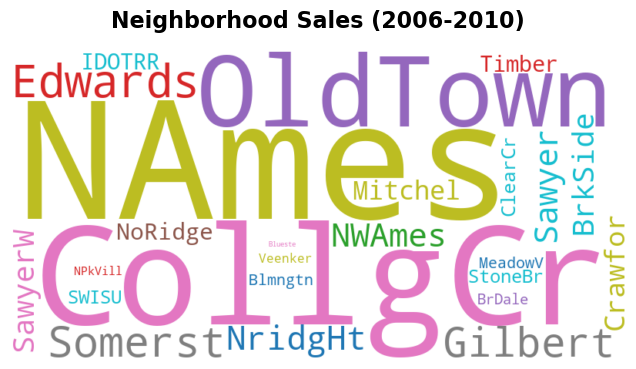

**Finding :** This word cloud shows which neighborhoods in Ames, Iowa had more houses sold compared to others. North Ames (NAmes) had the highest sales, followed by College Creek (CollgCr), Old Town (OldTown), and Edwards. The fewest sales were in Veenker, Bluestem, and Northpark Villa (NPkvill). This suggests that neighborhoods with more sales during this time may have been more affected by the financial crisis than those with fewer sales.

In [7]:
new_df = df_train.copy()
from wordcloud import WordCloud, STOPWORDS
# Filter for houses sold between 2006 and 2010
sales_period = new_df[new_df['YrSold'].between(2006, 2010)]

# Count sales per neighborhood
neighborhood_counts = sales_period['Neighborhood'].value_counts()

# Convert counts into a dictionary for weighting
ext = " ".join(sales_period['Neighborhood'])

# Generate word cloud (size of word = number of sales)
wordcloud = WordCloud(width=800, height=400, background_color="white",
                      colormap="tab10", max_words=100,
                      contour_color="k", contour_width=2).generate(ext)

# Display the word cloud
plt.figure(figsize=(8,4))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Neighborhood Sales (2006-2010)", fontsize=16, fontweight='bold', y=1.05)
plt.show()

display_md("**Finding :** This word cloud shows which neighborhoods in Ames, Iowa had more houses sold compared to others. North Ames (NAmes) had the highest sales, followed by College Creek (CollgCr), Old Town (OldTown), and Edwards. The fewest sales were in Veenker, Bluestem, and Northpark Villa (NPkvill). This suggests that neighborhoods with more sales during this time may have been more affected by the financial crisis than those with fewer sales.")


#### **1.1. Neighborhood and House Prices**

The dataset includes a feature called `Neighborhood`, which shows where each house is located. There are 25 neighborhoods in total, and we expect prices to vary between them. We demonstrate this with a bar plot.


,Neighborhood,avg_sales,relative_pct
0,NoRidge,335295.32,7.29
1,NridgHt,316270.62,14.17
2,StoneBr,310499.00,20.92
3,Timber,242247.45,26.19
4,Veenker,238772.73,31.38
5,Somerst,225379.84,36.28
6,ClearCr,212565.43,40.90


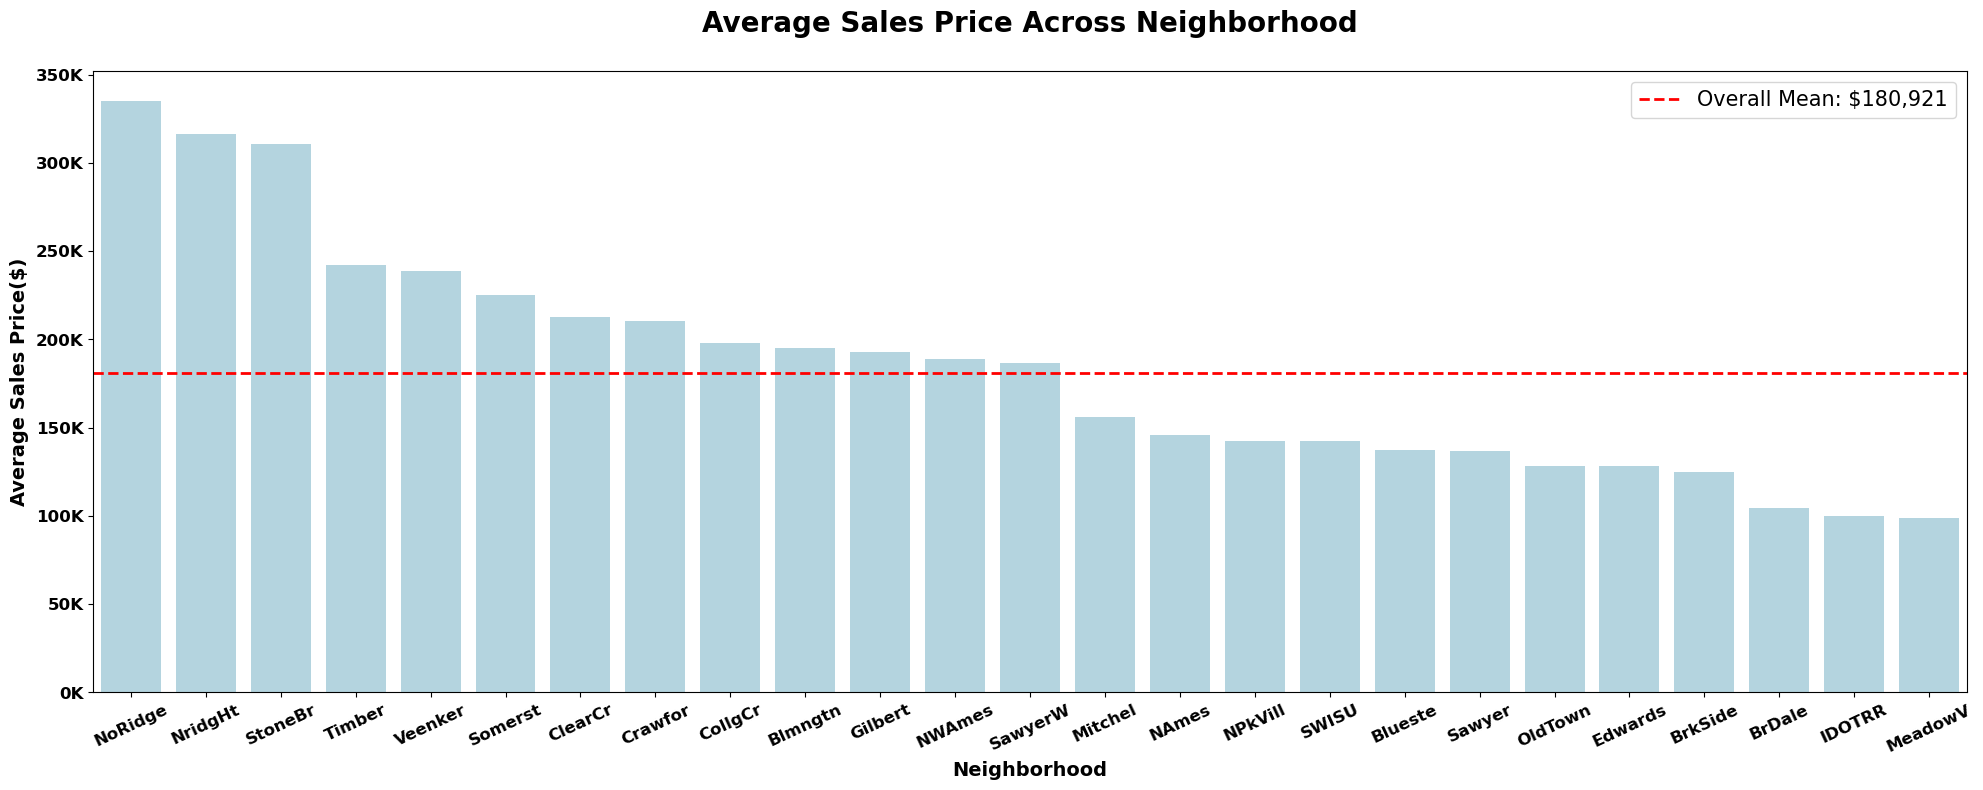

Average house prices vary across neighborhoods. Some neighborhoods exhibit notably higher average sale prices, which may suggest that it is located in a more desirable or affluent neighborhood . **Northridge has the highest average price, about three times that of Meadow Village, the lowest-priced neighborhood. Additionally, the top seven neighborhoods contribute about 41% of total property sales value, highlighting their significant contribution to the overall housing market.**

In [8]:
# Aggregate average sale price of house by neighborhood

avgsales_df = (
    new_df.groupby(['Neighborhood'])
    .agg(
        avg_sales = ("SalePrice", 'mean')
    )
    .sort_values(by='avg_sales',ascending=False)
    .reset_index()
)
avgsales_df = avgsales_df.assign(relative_pct = 100 *avgsales_df['avg_sales'].cumsum()/avgsales_df['avg_sales'].sum())
display(avgsales_df[:7])

# Visualization
fig, ax = plt.subplots(figsize=(20, 8))
# bar plot
sns.barplot(
    data=avgsales_df, 
    x='Neighborhood', y='avg_sales',
    color='lightblue', ax=ax)

# Overall mean of saleprice
overall_mean = new_df['SalePrice'].mean()
ax.axhline(overall_mean,
           color='r',
           lw=2, ls='--',
           label=f'Overall Mean: ${overall_mean:,.0f}')

ax.set_title("Average Sales Price Across Neighborhood", fontsize=20, fontweight='bold', y=1.05)
ax.set_xlabel("Neighborhood", fontsize=14, fontweight='bold', labelpad=5)
ax.set_ylabel("Average Sales Price($)", fontsize=14, fontweight='bold', labelpad=5)
ax.tick_params(axis='x', rotation=25)
ax.set_yticklabels([f"{y/1000:.0f}K" for y in ax.get_yticks()], fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontdict={'size':12, 'weight':'bold'})
ax.legend(fontsize=15)

plt.tight_layout()
plt.show()

display_md("Average house prices vary across neighborhoods. Some neighborhoods exhibit notably higher average sale prices, which may suggest that it is located in a more desirable or affluent neighborhood . **Northridge has the highest average price, about three times that of Meadow Village, the lowest-priced neighborhood. Additionally, the top seven neighborhoods contribute about 41% of total property sales value, highlighting their significant contribution to the overall housing market.**")



To see if the different house prices can be actually explained by neighborhoods, we create a dendrogram and examine if the houses in the same neighborhood form a cluster.
We use a dendrogram on `SalePrice` to identify clusters of house prices across neighborhoods.


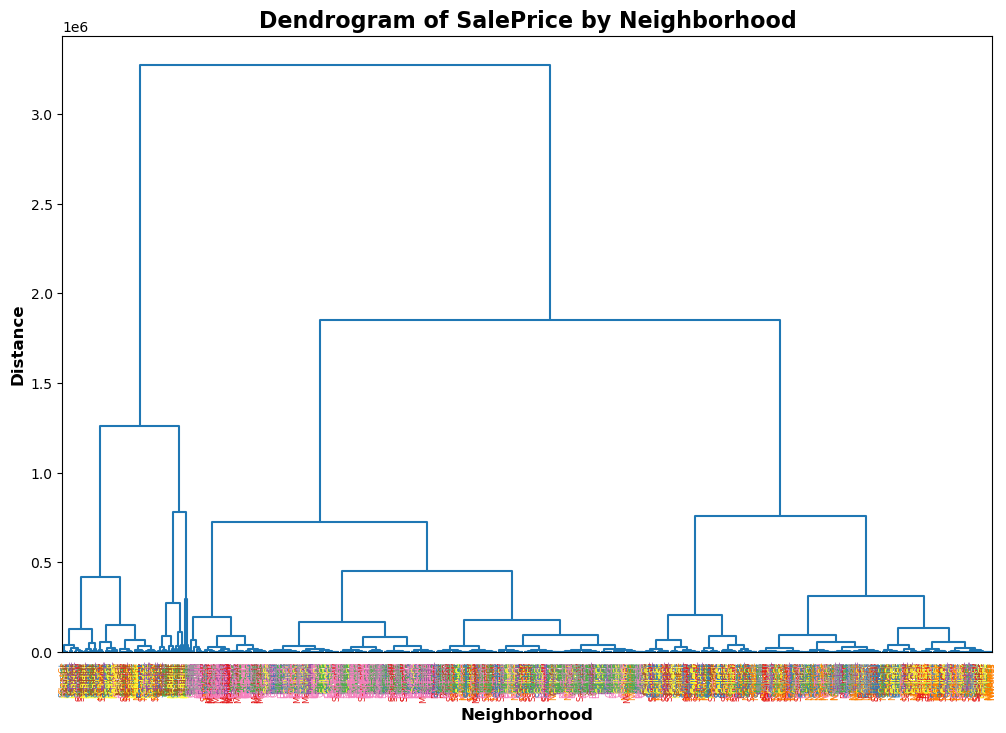

**Insight** :Once the clusters are formed, we display leaves and color them based on the neighborhood. Even though there are many houses, we just check if the same colors group together. They do--- yellow on the left, pink in the middle, green on the right and blue further right. **This indicate that houses within each neighborhood are similar to each other in terms of their sale prices.**

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import LabelEncoder

# Select SalePrice and Neighborhood
prices = new_df[["SalePrice", "Neighborhood"]]

# Encode neighborhoods into numeric labels for coloring
le = LabelEncoder()
prices["NeighborhoodCode"] = le.fit_transform(prices["Neighborhood"])

# Perform hierarchical clustering on SalePrice only
linked = linkage(prices[["SalePrice"]], method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 8))
dend = dendrogram(
    linked,
    labels=prices["Neighborhood"].values,
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=0  # ensures branches are colored
)

# Color the leaf labels by neighborhood
ax = plt.gca()
for lbl in ax.get_xticklabels():
    neighborhood = lbl.get_text()
    code = le.transform([neighborhood])[0]
    # Assign colors based on neighborhood code
    colors = plt.cm.Set1(code % 10)  # cycle through 20 distinct colors
    lbl.set_color(colors)

plt.title("Dendrogram of SalePrice by Neighborhood", fontsize=16, fontweight='bold')
plt.xlabel("Neighborhood", fontsize=12, fontweight='bold')
plt.ylabel("Distance", fontsize=12, fontweight='bold')
plt.show()

display_md("**Insight** :Once the clusters are formed, we display leaves and color them based on the neighborhood. Even though there are many houses, we just check if the same colors group together. They do--- yellow on the left, pink in the middle, green on the right and blue further right. **This indicate that houses within each neighborhood are similar to each other in terms of their sale prices.**")



Before examining how neighborhood affects the link between house size and sale price, will first categorize SalePrice into discrete ranges. Turning it into a factor will make each price bracket clearer, and to explore this, we visualize the distribution with a bar plot.

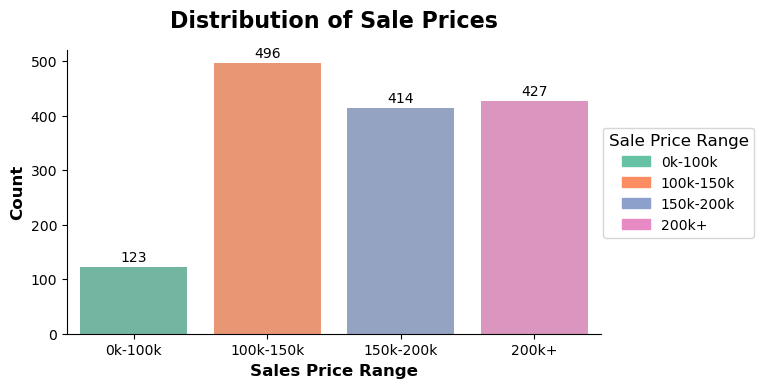

**Finding** :The chart shows four price categories, with most properties falling in the 100k-150k range, followed closely by 200k+. The 0-100k bracket has the fewest properties, highlighting a smaller market segment of propertied for lower‑priced homes.

In [10]:
# Define bins and labels
bins = [-float("inf"), 100000, 150000, 200000, float("inf")]
labels = ["0k-100k", "100k-150k", "150k-200k", "200k+"]

# Create the new categorical column
new_df["SalePriceRange"] = pd.cut(new_df["SalePrice"], 
                                  bins=bins, 
                                  labels=labels)

# Count values for each category
counts = new_df['SalePriceRange'].value_counts().sort_index()

# Create bar plot
plt.figure(figsize=(8,4))
sns.barplot(
    x=counts.index,
    y=counts.values,
    palette="Set2"
)

# Add count labels above bars
for i, val in enumerate(counts.values):
    plt.text(i, val + 5, str(val), ha='center', va='bottom')

# Add legend with custom colors
handles = [plt.Rectangle((0,0),1, 1, color=color)
           for color in sns.color_palette("Set2", n_colors = len(counts.index))]
plt.legend(handles, counts.index, title="Sale Price Range", title_fontsize=12, fontsize=10, loc='upper right', bbox_to_anchor=(1.30, 0.75), fancybox=True)

# Titles and labels
plt.title("Distribution of Sale Prices", fontsize=16, fontweight='bold', y=1.05)
plt.xlabel("Sales Price Range",fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')
sns.despine(right=True, top=True)

# Show plot
plt.tight_layout()
plt.show()

display_md("**Finding** :The chart shows four price categories, with most properties falling in the 100k-150k range, followed closely by 200k+. The 0-100k bracket has the fewest properties, highlighting a smaller market segment of propertied for lower‑priced homes.")



Explore the distribution of house size across different `SalePriceRange` categories. Visualize the trend through boxplot and add linear trend line to show the relationship between living arra size and sale price range.


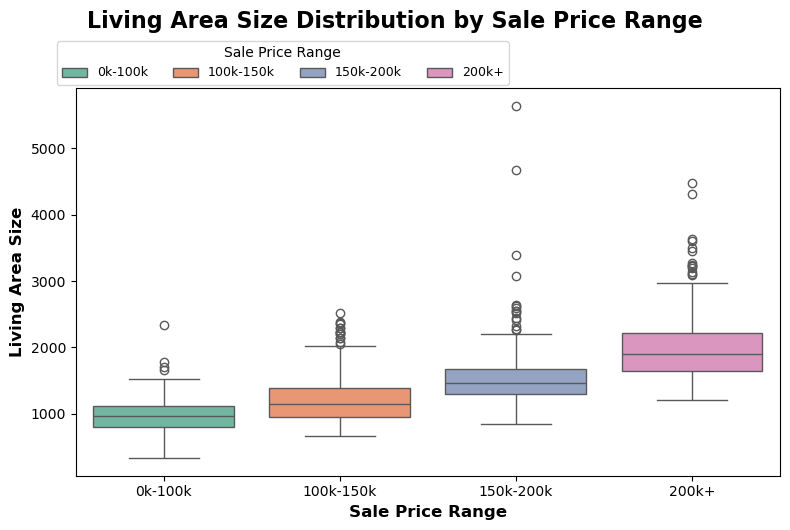

The boxplot, living area size Distribution by Sale Price Range, highlights the link between living area size and property price. **It shows a clear upward trend: as sale price ranges increase, house size also rises.** In particular, 0–100k category has the smallest median and a compact distribution, reflecting that lower-priced homes typically have smaller living spaces. while the 100k–150k and 150k–200k ranges show bigger and more varied living spaces. Properties in the 200k+ category stand out with the highest median and broadest spread, this indicates a significant variation in house sizes within this higher price category, which includes properties with significantly larger house size. but the presence of outliers shows that square foot alone does not determine property value. Other factors also influence pricing, and a fuller analysis would need to consider them.

In [11]:
import matplotlib.patches as mpatches


# Plot
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(
    data=new_df,
    x="SalePriceRange",
    y="GrLivArea",
    hue="SalePriceRange",
    #order=order,
    palette="Set2",
    legend=True, 
    ax=ax
)

fig.suptitle("Living Area Size Distribution by Sale Price Range",
          fontsize=16, fontweight="bold", y=1.05) 
ax.set_xlabel("Sale Price Range", fontsize=12, fontweight='bold')
ax.set_ylabel("Living Area Size", fontsize=12, fontweight='bold')
fig.legend(title='Sale Price Range', bbox_to_anchor=(0.65, 1), ncol=4, title_fontsize=10, fontsize=9)
ax.get_legend().remove()

plt.tight_layout()
plt.show()

display_md("The boxplot, living area size Distribution by Sale Price Range, highlights the link between living area size and property price. **It shows a clear upward trend: as sale price ranges increase, house size also rises.** In particular, 0–100k category has the smallest median and a compact distribution, reflecting that lower-priced homes typically have smaller living spaces. while the 100k–150k and 150k–200k ranges show bigger and more varied living spaces. Properties in the 200k+ category stand out with the highest median and broadest spread, this indicates a significant variation in house sizes within this higher price category, which includes properties with significantly larger house size. but the presence of outliers shows that square foot alone does not determine property value. Other factors also influence pricing, and a fuller analysis would need to consider them.")


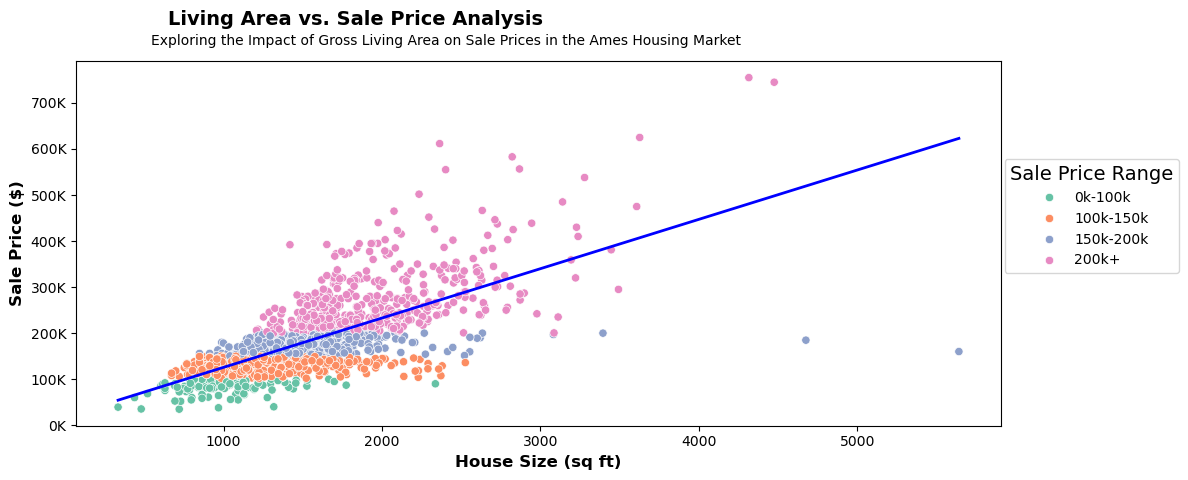

The scatter plot shows that larger living areas generally correspond to higher sale prices, with properties over 4,000 square feet standing out as outliers. While size influences house price, these exceptions(outliers) suggest other factors also play a role. The color-coded layers create a clear stratification of price ranges across different living area sizes.

In [12]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(12,5))

# Scatter plot 
sns.scatterplot(
    data=new_df,
    x="GrLivArea",
    y="SalePrice",
    hue="SalePriceRange",
    palette="Set2",
    ax=ax
)

# Add trend line for relationship of house size and price
sns.regplot(
    data=new_df,
    x='GrLivArea', y='SalePrice',
    scatter=False, ci=None,
    color='b', line_kws={'ls':'-', 'lw':2},
    ax=ax
)

# Titles and labels and legend
ax.legend(title='Sale Price Range', title_fontsize=14, loc='upper right', bbox_to_anchor=(1.2, 0.75), fancybox=True)
fig.suptitle("Living Area vs. Sale Price Analysis", fontsize=14, fontweight="bold", y=0.95, x=0.3)
ax.set_title("Exploring the Impact of Gross Living Area on Sale Prices in the Ames Housing Market", fontsize=10, y=1.02, x=0.4)
ax.set_xlabel("House Size (sq ft)", fontsize=12, fontweight='bold')
ax.set_ylabel("Sale Price ($)", fontsize=12, fontweight='bold')


# Format y-axis 
ax.set_yticklabels([f"{y/1000:.0f}K" for y in ax.get_yticks()])

# Adjust layout
plt.tight_layout()
plt.show()

display_md("The scatter plot shows that larger living areas generally correspond to higher sale prices, with properties over 4,000 square feet standing out as outliers. While size influences house price, these exceptions(outliers) suggest other factors also play a role. The color-coded layers create a clear stratification of price ranges across different living area sizes.")



#### **1.2. Relationship between living-area and saleprice can vary across neighborhoods**

We know house prices vary by location and exhibit a strong correlation with living-area, but we also want to see if the link between house size and its price is different across neighborhoods. We can expect that bigger houses usually cost more, but is this increase in price the same for different location/areas?

We expect this relationship to vary across neighborhoods, since some areas are more desirable due to factors like facilities, safety and transportation. To explore this, we visualizing the relationship through a scatter plot, using above-ground living area (sq. ft.) as a measure of living-area.


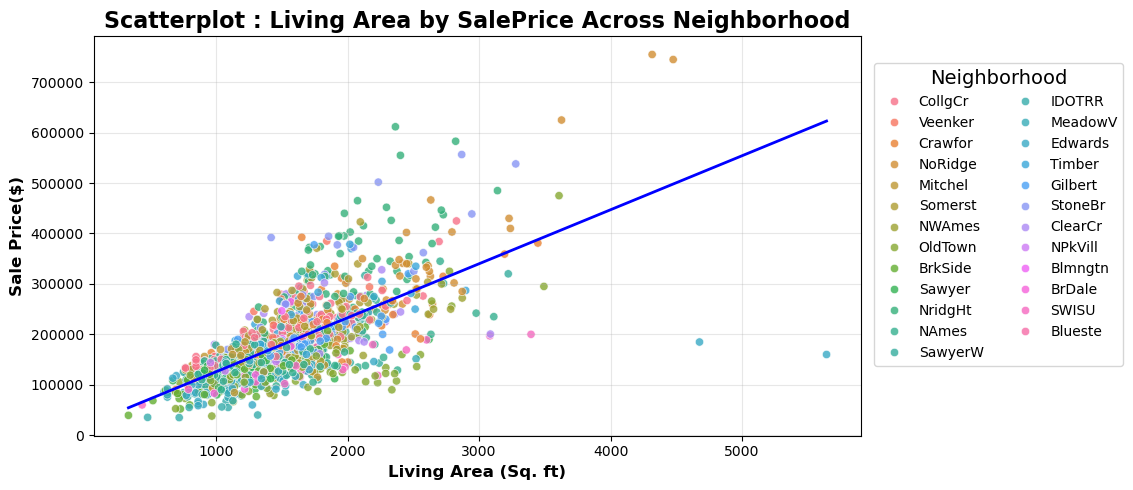

**The scatterplot shows a clear positive relationship between living area & sale price---larger homes sell for more. The relationship appears fairly linear, meaning there isn't an extra premium per square foot for very large houses.**

In [13]:
# Visualizing scatter plot
fig, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(
    data=new_df,
    x='GrLivArea',
    y='SalePrice',
    hue='Neighborhood', palette='husl',
    alpha=0.8,
    ax=ax
)

# Add trend line for relationship of house size and price
sns.regplot(
    data=new_df,
    x='GrLivArea', y='SalePrice',
    scatter=False, ci=None,
    color='b', line_kws={'ls':'-', 'lw':2},ax=ax
)

ax.set_title("Scatterplot : Living Area by SalePrice Across Neighborhood", fontsize=16, fontweight='bold')
ax.set_xlabel("Living Area (Sq. ft)", fontsize=12, fontweight='bold')
ax.set_ylabel("Sale Price($)", fontsize=12, fontweight='bold')
ax.legend(title='Neighborhood', title_fontsize=14, loc='upper right', bbox_to_anchor=(1.35, 0.95), ncol=2, fancybox=True)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
display_md("**The scatterplot shows a clear positive relationship between living area & sale price---larger homes sell for more. The relationship appears fairly linear, meaning there isn't an extra premium per square foot for very large houses.**")



To compare prices across neighborhoods more accurately, we should adjust for house size by using price per square foot, which highlights the location‑based premium beyond size.

We can now plot sale price per square foot by neighborhood using a box plot. If location, does not have a relationship with sale price per square foot, then the boxplots will have similar medians and interquartile ranges. If location does have a relationship with sale price per square foot, then the boxplots differ in its median and interquartile ranges.


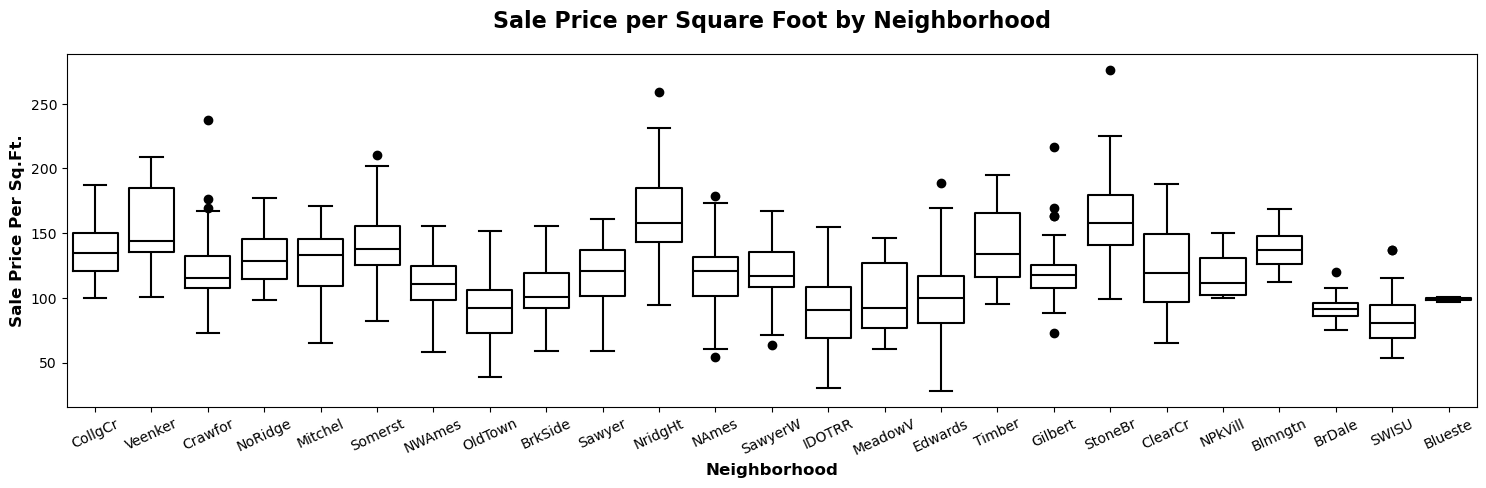

**The box plots show that houses in certain neighborhoods sell for higher prices per square foot, and that this relationship remains even after controlling for house size. This indicates that location is an important factor in predicting housing prices.**

In [14]:
# Computing sale price per square feet, divide the sale price of the house by its living area (in square feet).
new_df['PricePerSF'] = new_df['SalePrice']/new_df['GrLivArea']

# visualize sale price per sq ft by Neighborhood
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(
    data=new_df, 
    x='Neighborhood', y='PricePerSF',
    fill=False, color='k',
    flierprops=dict(marker='o', markerfacecolor='k'),
    ax=ax)
ax.tick_params(axis='x', rotation=25)
ax.set_title("Sale Price per Square Foot by Neighborhood", fontsize=16, fontweight='bold', y=1.05)
ax.set_xlabel("Neighborhood", fontsize=12, fontweight='bold')
ax.set_ylabel("Sale Price Per Sq.Ft.", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

display_md("**The box plots show that houses in certain neighborhoods sell for higher prices per square foot, and that this relationship remains even after controlling for house size. This indicates that location is an important factor in predicting housing prices.**")



##### **Hypothesis Testing :**

The above visualization showd us price per Sq ft vary by neighborhoods, but they do not tell us whether neighborhoods is statistically significant predictor.

`Question 1` : Do Average price-per-sq-ft values vary across neighborhoods?

For this, will run .The ANOVA here is a global F‑test comparing mean PricePerSF differs across neighborhoods. It's essentially a one-way ANOVA. And this, confirming that at least some neighborhoods differ significantly in price per square foot compared to the base neighborhood.

In [15]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Run the global F-test (ANOVA-style test)
model = ols('PricePerSF ~ C(Neighborhood)', data=new_df).fit()

# Perform ANOVA (global F-test)
anova_results = sm.stats.anova_lm(model, typ=2)
print(anova_results)

display_md("**The global F‑test indicates that neighborhood is a statistically significant predictor of price per square foot, meaning at least one neighborhood differs from the base neighborhood in a meaningful way.The box plots and the global F-test lead to the same conclusion.**")


                   sum_sq      df     F  PR(>F)
C(Neighborhood) 557703.26   24.00 37.89    0.00
Residual        879995.27 1435.00   NaN     NaN


**The global F‑test indicates that neighborhood is a statistically significant predictor of price per square foot, meaning at least one neighborhood differs from the base neighborhood in a meaningful way.The box plots and the global F-test lead to the same conclusion.**

Will explore the relationship between house size(represented as living area above ground in sq. ft.) and sale price depends on the neighborhood.

`Question 2` : Does the relationship between house size and sale price significantly vary by neighborhood?

To confirm this hypothesis will apply ANOVA test.


In [16]:
# Model 1: additive effects
# This model assumes that house size (GrLivArea) and neighborhood each affect sale price independently.
# The slope of the relationship between size and price is the same across all neighborhoods.
# Neighborhood only shifts the baseline (intercept), not the slope.
# Story: "Bigger houses cost more, and some neighborhoods are generally more expensive, but the rate at which price increases with size is constant everywhere."

model1 = ols('SalePrice ~ GrLivArea + C(Neighborhood)',data=new_df).fit()

# Model 2: includes interaction between GrLivArea and Neighborhood
# This model allows for an interaction between house size and neighborhood.
# The slope of the size-price relationship can differ across neighborhoods.
# Neighborhoods can have both different baselines (intercepts) and different slopes.
# Story: "In some neighborhoods, extra square footage adds a lot to the price, while in others, size matters less."

model2 = ols('SalePrice ~ GrLivArea * C(Neighborhood)',data=new_df).fit()

# Compare the two models with ANOVA (global F-test)
anova_results = sm.stats.anova_lm(model1, model2, typ=1)
print(anova_results)

display_md("The ANOVA test gave F = 17.48 with 24 and 1410 degrees of freedom. The p‑value is essentially zero, which is below 0.05. This means we reject the null hypothesis and conclude that the link between house size and sale price varies by neighborhood. We can't say exactly which neighborhood causes the difference, but at least one of them does. **In other words, the effect of size on price depends on neighborhood.**")



   df_resid              ssr  df_diff         ss_diff     F  Pr(>F)
0   1434.00 2407736053147.33     0.00             NaN   NaN     NaN
1   1410.00 1855570606841.92    24.00 552165446305.41 17.48    0.00


The ANOVA test gave F = 17.48 with 24 and 1410 degrees of freedom. The p‑value is essentially zero, which is below 0.05. This means we reject the null hypothesis and conclude that the link between house size and sale price varies by neighborhood. We can't say exactly which neighborhood causes the difference, but at least one of them does. **In other words, the effect of size on price depends on neighborhood.**

---

### **`Question 2.` How does the different type of zoning affect property prices?**

Zoning laws decide how land can be used -- whether for homes, businesses, or farming -- and this directly affects property values. Sales ddata show clear differences : low-density residential areas often command higherr prices becasue families prefer spacious living, while commercial zones gain value from their accessibility and closeness to economic activity.


**Types of MSZoning and Their Notations**

| Code | Description |
|------|-------------|
| A    | Agriculture |
| C    | Commercial |
| FV   | Floating Village Residential |
| I    | Industrial |
| RH   | Residential High Density |
| RL   | Residential Low Density |
| RP   | Residential Low Density Park |
| RM   | Residential Medium Density |

**Univariate Analysis**


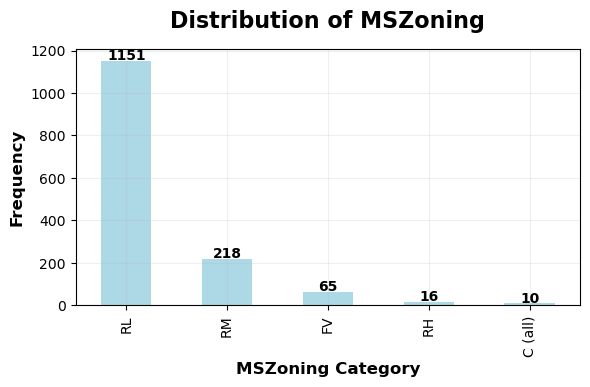

In [17]:
# Step 1: Look at the distribution of MSZoning
counts = new_df['MSZoning'].value_counts()

# Step 2: Visualize the distribution of MSZoning
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', color='lightblue', ax=ax)
ax.set_title("Distribution of MSZoning", fontsize=16, fontweight='bold', y=1.05)
ax.set_xlabel("MSZoning Category", fontsize=12, fontweight='bold')
ax.set_ylabel("Frequency", fontsize=12, fontweight='bold')

# Annotate the bars with counts
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


`Question`: To formally test whether the MSZoning distribution is uniform (or follows some expected pattern), will use Chi-Square Goodness-of-Fit Test.

**Null Hypothesis :** The categories of MSZoning follow a uniform distribution (all zones equally likely).

**Alternative Hypothesis :** The categories of MSZoning do not follow a uniform distribution (some zones are more/less frequent).


In [18]:
# Step 3: Perform chi-square goodness of fit test

from scipy.stats import chisquare

# Count houses in each zoning category
zone_counts = new_df['MSZoning'].value_counts()

# Expected counts under uniform distribution (uniform: each category equally likely)
expected_counts = [len(new_df) / len(zone_counts)] * len(zone_counts)

# Perform chi-square test
stat = chisquare(f_obs=zone_counts, f_exp=expected_counts)

print(f"Chi-square statistic:, {stat.statistic:.2f}")
print("Degrees of freedom:", len(zone_counts) - 1)
print("p-value:", stat.pvalue)

# Interpretation
alpha = 0.05
if stat.pvalue < alpha:
    print("\nReject H₀: Distribution is not uniform across zoning classifications.")
else:
    print("\nFail to reject H₀: Distribution may be uniform.")


Chi-square statistic:, 3255.43
Degrees of freedom: 4
p-value: 0.0

Reject H₀: Distribution is not uniform across zoning classifications.


__Bivariate Analysis__

##### __How different type of Mszoning affect house price?__


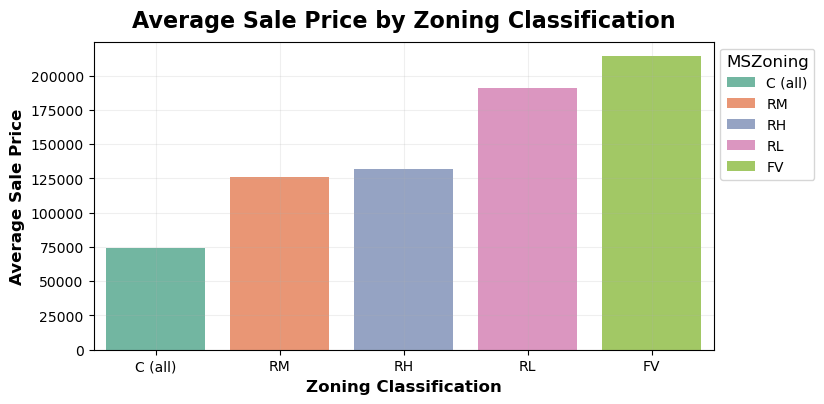

We looked at how house prices vary by zoning classifiaction. Zoning affects how towns and cities develop, and here it also influencecs saleprice. The categories include Commercial(C), Floating Village Residential(FV), and Residential zones with High(RH), Medium(RM), and Low(RL) density. FV homes are unique because they're built on water bodies. The bar chart shows that FV and RL zones have the highest average sale prices, while RH and RM are lowwer but still above Commercial zones. Overall, residential zones(FV, RL) sell for more than commercial ones, with FV homes commanding the highest valuation.

In [19]:
avg_prices = new_df.groupby('MSZoning')['SalePrice'].mean().reset_index().sort_values(by='SalePrice', ascending=True)

# Plot with colors and legend
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=avg_prices,
            x='MSZoning',
            y='SalePrice',
            hue='MSZoning',
            palette='Set2',
            legend=True,
            ax=ax)

ax.set_title('Average Sale Price by Zoning Classification', fontsize=16, fontweight='bold', y=1.02)
ax.set_ylabel('Average Sale Price', fontsize=12, fontweight='bold')
ax.set_xlabel('Zoning Classification', fontsize=12, fontweight='bold')
ax.legend(title='MSZoning', title_fontsize=12, bbox_to_anchor=(1, 1),)

plt.grid(True, alpha=0.2)
plt.show()

display_md("We looked at how house prices vary by zoning classifiaction. Zoning affects how towns and cities develop, and here it also influencecs saleprice. The categories include Commercial(C), Floating Village Residential(FV), and Residential zones with High(RH), Medium(RM), and Low(RL) density. FV homes are unique because they're built on water bodies. The bar chart shows that FV and RL zones have the highest average sale prices, while RH and RM are lowwer but still above Commercial zones. Overall, residential zones(FV, RL) sell for more than commercial ones, with FV homes commanding the highest valuation.")



The bar chart illustrates how average house prices differ across MSZoning categories. While these group-wise variations are visually apparent, statistical testing is needed to confirm whether the differences are significant rather than due to random variation. To assess this formally, we apply an ANOVA test.

In [20]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit OLS model with SalePrice as dependent variable and MSZoning as categorical predictor
model = ols('SalePrice ~ C(MSZoning)', data=new_df).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model, type=2)  # type=2 for Type II ANOVA

print(anova_results)
# Extract p-value from ANOVA results
p_value = anova_results['PR(>F)'][0]
if p_value < 0.05:
    print(f"\nANOVA Result: Statistically significant difference in average SalePrice across MSZoning categories (p-value = {p_value:.4f}).")
    print("Proceeding with Tukey's HSD test for pairwise comparisons.")

# If significant, run Tukey’s HSD : Show which pairs (e.g., RL vs RM, RL vs FV) differ significantly.

from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=new_df['SalePrice'], groups=new_df['MSZoning'], alpha=0.05)
print("\n Tukey's HSD Results:")
print(tukey)

display_md("- __RL (Low Density) homes__ consistently sell for more than RM and RH zones")
display_md("- __FV (Floating Village) homes__ are also high-value, significantly above RM and RH")
display_md("- __Commercial (C)__ properties are much cheaper than RL and FV")
display_md("- Some differences (like FV vs RL, RH vs RM) are not statistically significant, meaning prices overlap enough that we can't confidently say one is higher")

display_md("**Key Finding :** The MSZoning variable significantly influence the house prices. Properties located in RL and FV zones consistently recieve premium valuations, whereas those situated in RM, RH, and C zones are priced at comparatively lower levels.")



                 df           sum_sq         mean_sq     F  PR(>F)
C(MSZoning)    4.00  990400028351.79 247600007087.95 43.84    0.00
Residual    1455.00 8217511306258.19   5647774093.65   NaN     NaN

ANOVA Result: Statistically significant difference in average SalePrice across MSZoning categories (p-value = 0.0000).
Proceeding with Tukey's HSD test for pairwise comparisons.

 Tukey's HSD Results:
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
 group1 group2   meandiff  p-adj     lower        upper    reject
-----------------------------------------------------------------
C (all)     FV 139486.0615    0.0   69764.6598 209207.4633   True
C (all)     RH   57030.375 0.3272   -25710.258  139771.008  False
C (all)     RL 116476.9948    0.0   51288.5523 181665.4372   True
C (all)     RM  51788.8303 0.2075  -14590.2657 118167.9262  False
     FV     RH -82455.6865 0.0008 -139737.6632 -25173.7098   True
     FV     RL -23009.0668 0.1154  -49176.7096   3158.5761  False
   

- __RL (Low Density) homes__ consistently sell for more than RM and RH zones

- __FV (Floating Village) homes__ are also high-value, significantly above RM and RH

- __Commercial (C)__ properties are much cheaper than RL and FV

- Some differences (like FV vs RL, RH vs RM) are not statistically significant, meaning prices overlap enough that we can't confidently say one is higher

**Key Finding :** The MSZoning variable significantly influence the house prices. Properties located in RL and FV zones consistently recieve premium valuations, whereas those situated in RM, RH, and C zones are priced at comparatively lower levels.

Now, will explore how house prices differ by zoning type and also highlights that some categories have very few data points, visualize this through heatmap below.

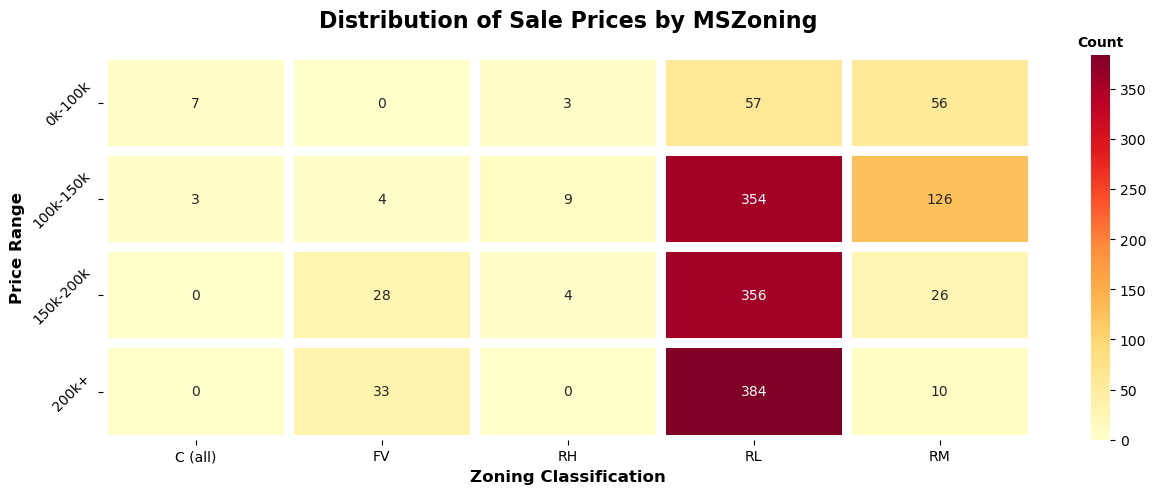

The darker colors on the heatmap show where the most homes were sold in a given price range and zoning classifiaction. Most sales occurred in the RL zone. No commercial property sold for more than 150K (in dollars), and no FV homes sold for less than 100K (in dollars). This suggest that most typical homes in Ames are low-density residential and relatively expensive compared to other zones. Overall, RL and RM zones have most number of sales with a wide range of prices, FV has fewer but higher-priced sales, and commercial zones have the lowest sales and prices.

In [21]:
# Divide SalePrice into bins
# new_df['PriceBin'] = pd.cut(new_df['SalePrice'],
#                         bins=[0, 135000, 250000, 350000, 450000, 550000, 650000, 800000],
#                         labels=['0-135k','135-250k','250-350k','350-450k', '450-550k', '550-650k', '650-800k'])

# Create a pivot table: counts of properties by zoning and price bin
heatmap_data = new_df.pivot_table(index='SalePriceRange', columns='MSZoning', 
                              values='SalePrice', aggfunc='count', fill_value=0)

# Plot heatmap
plt.figure(figsize=(15, 5))
ax = sns.heatmap(heatmap_data, annot=True, fmt="d", lw=6, cmap="YlOrRd")

# Move colorbar title to the top
cbar = ax.collections[0].colorbar
#cbar.set_label('Count', labelpad=10)
cbar.ax.set_title('Count', fontsize=10, fontweight='bold')

plt.title('Distribution of Sale Prices by MSZoning', fontsize=16, fontweight='bold', y=1.05)
plt.xlabel('Zoning Classification', fontsize=12, fontweight='bold')
plt.ylabel('Price Range', fontsize=12, fontweight='bold')
plt.yticks(rotation=45)
plt.show()

display_md("The darker colors on the heatmap show where the most homes were sold in a given price range and zoning classifiaction. Most sales occurred in the RL zone. No commercial property sold for more than 150K (in dollars), and no FV homes sold for less than 100K (in dollars). This suggest that most typical homes in Ames are low-density residential and relatively expensive compared to other zones. Overall, RL and RM zones have most number of sales with a wide range of prices, FV has fewer but higher-priced sales, and commercial zones have the lowest sales and prices.")



---
### **Conclusion**

This analysis explored the Ames, Iowa housing market and examined how different house's neigborhood and zoning related to sale prices.


**`Neighborhood & House Price Analysis`** : We studied, average house prices vary across neighborhoods. Some areas have much higher prices. Houses within each neighborhood are similar to each other in terms of their sale prices. Our study shows that housing prices in Ames, Iowa are strongly influenced by location. Even after house size is controlled, certain neighborhoods still sell for more per square foot, showing that some areas carry a premium. bigger homes tend to be more expensive, the housing market shows wide variation within each price bracket, reflecting the complexity of property valuation.. Additionally, the effect of size on price depends on neighborhood.

**`Zoning's Impact`**: We discovered that zoning classifications significantly influence saleprices, with residential zones generally commanding higher prices than commercial ones. The rarity and uniqueness of Floating Village Residential zones particularly command premium prices.



In [22]:
print("="*65 + " COMPLETED " + "="*65)

================================================================= COMPLETED =================================================================
